In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv("Mall_Customers.csv")
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [4]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [5]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [6]:
encoder = LabelEncoder()
df['Gender'] = encoder.fit_transform(df['Gender'])

In [7]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [8]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )
    
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

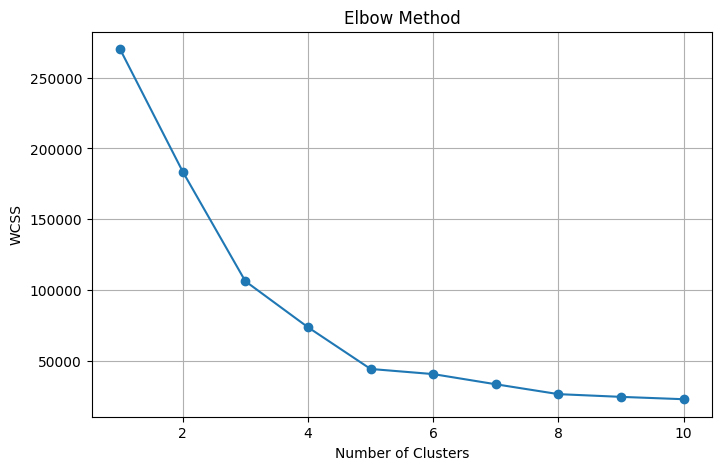

In [9]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [10]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

In [11]:
y_kmeans = kmeans.fit_predict(X)
df['Cluster'] = y_kmeans

print("\nClustered Data:")
print(df.head())


Clustered Data:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1       1   19                  15                      39   
1           2       1   21                  15                      81   
2           3       0   20                  16                       6   
3           4       0   23                  16                      77   
4           5       0   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


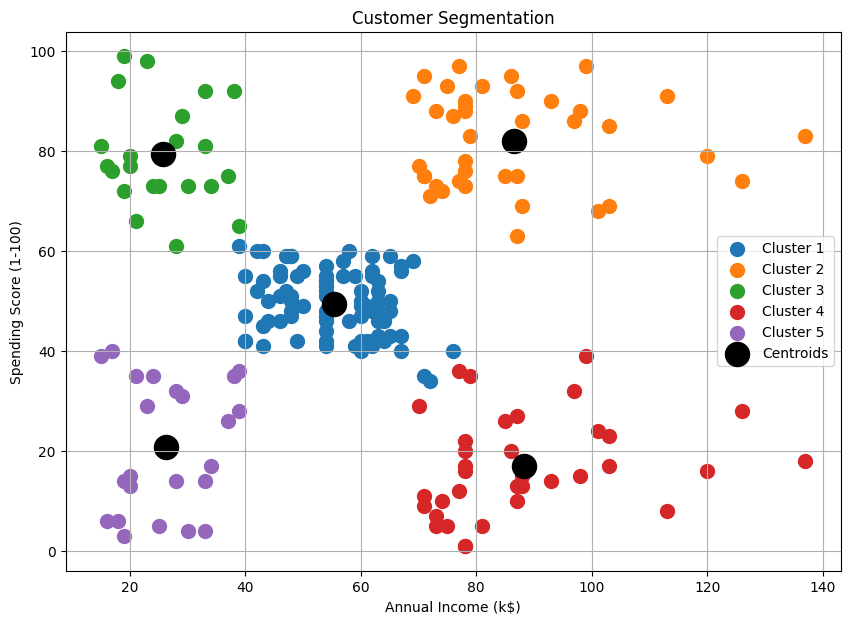


Customers in Cluster 0:
     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
43           44       0   31                  39                      61   
46           47       0   50                  40                      55   
47           48       0   27                  40                      47   
48           49       0   29                  40                      42   
49           50       0   31                  40                      42   
..          ...     ...  ...                 ...                     ...   
121         122       0   38                  67                      40   
122         123       0   40                  69                      58   
126         127       1   43                  71                      35   
132         133       0   25                  72                      34   
142         143       0   28                  76                      40   

     Cluster  
43         0  
46         0  
47         0  
48

In [12]:
plt.figure(figsize=(10,7))

plt.scatter(
    X.iloc[y_kmeans == 0, 0],
    X.iloc[y_kmeans == 0, 1],
    s=100,
    label='Cluster 1'
)

plt.scatter(
    X.iloc[y_kmeans == 1, 0],
    X.iloc[y_kmeans == 1, 1],
    s=100,
    label='Cluster 2'
)

plt.scatter(
    X.iloc[y_kmeans == 2, 0],
    X.iloc[y_kmeans == 2, 1],
    s=100,
    label='Cluster 3'
)

# Cluster 4
plt.scatter(
    X.iloc[y_kmeans == 3, 0],
    X.iloc[y_kmeans == 3, 1],
    s=100,
    label='Cluster 4'
)

plt.scatter(
    X.iloc[y_kmeans == 4, 0],
    X.iloc[y_kmeans == 4, 1],
    s=100,
    label='Cluster 5'
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    c='black',
    label='Centroids'
)

plt.title('Customer Segmentation')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)

plt.show()

for i in range(5):
    print(f"\nCustomers in Cluster {i}:")
    print(df[df['Cluster'] == i])

In [13]:
print("\nEnter New Customer Details")

income = float(input("Enter Annual Income: "))
score = float(input("Enter Spending Score (1-100): "))

new_customer = [[income, score]]
predicted_cluster = kmeans.predict(new_customer)

print("\nCustomer belongs to Cluster:", predicted_cluster[0])


Enter New Customer Details


Enter Annual Income:  20
Enter Spending Score (1-100):  9



Customer belongs to Cluster: 4


C:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
